# Sea-surface height data

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/aselshall/eds/HEAD)

---

In [1]:
import os
import copernicusmarine
import shutil

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature


import math
from scipy.io import loadmat  # this is the SciPy module that loads mat-files
from statsmodels.nonparametric.smoothers_lowess import lowess
#from PyEMD import EMD

import warnings
#  Suppress warnings issued by Cartopy when downloading data files
warnings.filterwarnings('ignore')

Going With the Flow: Visualizing Ocean Currents with ECCO   
https://science.nasa.gov/earth/oceans/going-with-the-flow-visualizing-ocean-currents-with-ecco/

https://link.springer.com/article/10.1038/s43247-025-02108-4 

For publishing do HBMA with zos average, delta, and track 26


---

## 1. Problem Statement

The hypothesis is that high sea-level anomalies in the Gulf of Mexico is a  a necessary condition for the occurance of red tides (high concentration of K. brevis cell counts) in the West Florida shielf. High sea-level anomalies is asscoiated with the Gulf Loop Current, which is a warm ocean current that flows from the Caribbean to the Gulf of Mexico, then loops east and south along the Florida coast, and exits through the Straits of Florida. To investigate the relationship between sea level anomalies (SLA) and red tide occurrences (K. brevis cell counts), we you can employ several statistical methods such as time series analysis, regression analysis, event study analysis, spatial correlation analysis and machine learning models. The objective of this exercise is to prepare data for analysis. Specifically, our tasks are to:
- download and reduce monthly 3d (x,y, time) SLA data to monthly 2d (x, time) data
- download and reduce daily 3d (x,y, time) K. brevis data to weekly 1d (time) data
- Redue monthly 2D (x, time) sla data into to weekly 1d (time) data with temporal alignment with K. brevis data
- transform weekly 1d SLA and K. brevs data with techniques for stationarity, detrending, zero mean, normalization, etc.

This is all needed so the we you can directly compare SLA data with K. brevis cell count data and perform statstical analysis.

## 2. Exploring SLA data

### 2.1 Download global data (*optional*)

From [Climate Data Store (CDS)](https://cds.climate.copernicus.eu/#!/home) you can download the [Sea level gridded data from satellite observations for the global ocean from 1993 to present](
https://cds.climate.copernicus.eu/cdsapp#!/dataset/satellite-sea-level-globa). You can manually download the data from CDS website or through API. This [link](
https://cds.climate.copernicus.eu/api-how-to#install-the-cds-api-ke) contains information on how to use the CDS API and API key. Additional information can be found in this [link](https://confluence.ecmwf.int/display/CKB/How+to+install+and+use+CDS+API+on+Windows).

To run the code below, you need first to set the CDS API key.

https://data.marine.copernicus.eu/products 

https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_PHY_001_030/description

In [2]:
# Duration configuration (Month, Day)
select_duration=1
duration = ['M', 'D']
zos_folder = f"../../raw_data/zos_{duration[select_duration]}"

In [3]:
#Download data if does not exit
download_data= False
if download_data:
    # Configuration for both time periods and datasets
    configs = [
        {
            'start_datetime': "1993-01-01T00:00:00",
            'end_datetime': "2021-06-01T00:00:00",
            'dataset_id': f"cmems_mod_glo_phy_my_0.083deg_P1{duration[select_duration]}-m"
        },
        {
            'start_datetime': "2021-07-01T00:00:00",
            'end_datetime': "2025-02-01T00:00:00",
            'dataset_id': f"cmems_mod_glo_phy_myint_0.083deg_P1{duration[select_duration]}-m"
        }
    ]
    
    # Ensure 'zos' folder exists
    if not os.path.exists(zos_folder):
        os.makedirs(zos_folder)
    
    # Loop through both configurations and download data
    for config in configs:
        print(f"Downloading data from {config['start_datetime']} to {config['end_datetime']}...")
        
        output = copernicusmarine.subset(
            dataset_id=config['dataset_id'],
            dataset_version="202311",
            #variables=["zos"],
            variables=["thetao"],
            #minimum_longitude=-100,
            #maximum_longitude=-75,
            #minimum_latitude=18,
            #maximum_latitude=32,

            minimum_longitude=-85,
            maximum_longitude=-81,
            minimum_latitude=25,
            maximum_latitude=28,
            start_datetime=config['start_datetime'],
            end_datetime=config['end_datetime'],
            minimum_depth=0.49402499198913574,
            #maximum_depth=0.49402499198913574,
            maximum_depth=3,

            coordinates_selection_method="strict-inside",
            disable_progress_bar=False,
            username="aelshall",
            password="@lhmedAllah11"
        )
    
        # Extract file path from the ResponseSubset object
        output_file = output.file_path if hasattr(output, 'file_path') else None
        
        # Move file to zos folder if it exists
        if output_file:
            destination = os.path.join(zos_folder, os.path.basename(output_file))
            shutil.move(output_file, destination)
            print(f"File moved to {destination}")
        else:
            print(f"No file downloaded for {config['start_datetime']} to {config['end_datetime']}. Check dataset settings.")
    
    print("All downloads complete.")


### 2.2 Select and save Gulf of Mexico data (*optional*)

We need to extract the Gulf of Mexico data from this global dataset as follows.

In [4]:
# Read all files
ds = xr.open_mfdataset(f"{zos_folder}/*.nc", combine="by_coords")  # , parallel=True

In [5]:
# Display dataset
ds

<xarray.Dataset> Size: 5GB
Dimensions:    (time: 11716, latitude: 169, longitude: 301)
Coordinates:
  * latitude   (latitude) float32 676B 18.0 18.08 18.17 ... 31.83 31.92 32.0
  * longitude  (longitude) float32 1kB -100.0 -99.92 -99.83 ... -75.08 -75.0
  * time       (time) datetime64[ns] 94kB 1993-01-01 1993-01-02 ... 2025-01-28
Data variables:
    zos        (time, latitude, longitude) float64 5GB dask.array<chunksize=(10408, 169, 301), meta=np.ndarray>
Attributes:
    title:                     daily mean fields from Global Ocean Physics An...
    comment:                   CMEMS product
    Conventions:               CF-1.4
    source:                    MERCATOR GLORYS12V1
    institution:               MERCATOR OCEAN
    history:                   2023/06/01 16:20:05 MERCATOR OCEAN Netcdf crea...
    references:                http://www.mercator-ocean.fr
    copernicusmarine_version:  2.0.1


 Plot saved to: figures/zos_plot_output.png


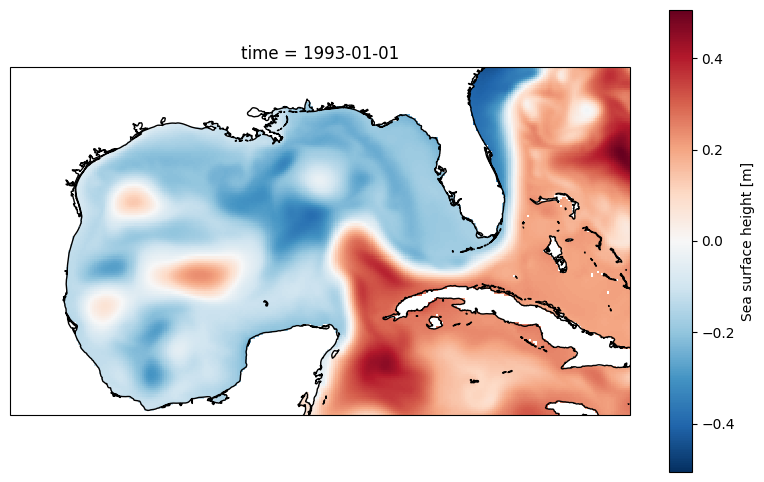

In [6]:
# Display 2d data  at the first time step
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ds.zos[0,:,:].plot()
ax.coastlines();

# Save the figure
output_path = 'figures/zos_plot_output.png'  # Specify the desired output path and filename
plt.savefig(output_path, dpi=300)  # Save with high resolution
print(f"\n Plot saved to: {output_path}")

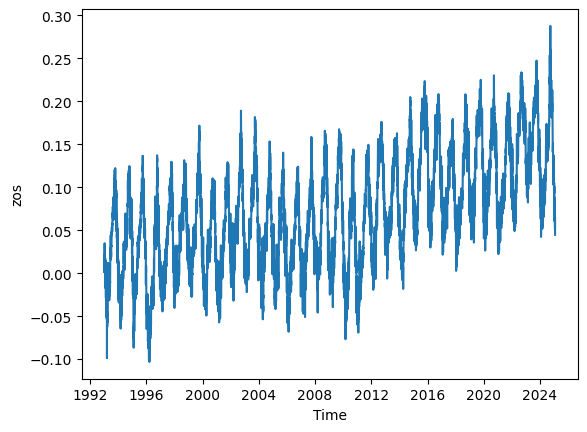

In [7]:
# Calculate the mean zos across the 'latitude' and 'longitude' dimensions
mean_zos = ds.zos.mean(dim=('latitude', 'longitude')).plot()

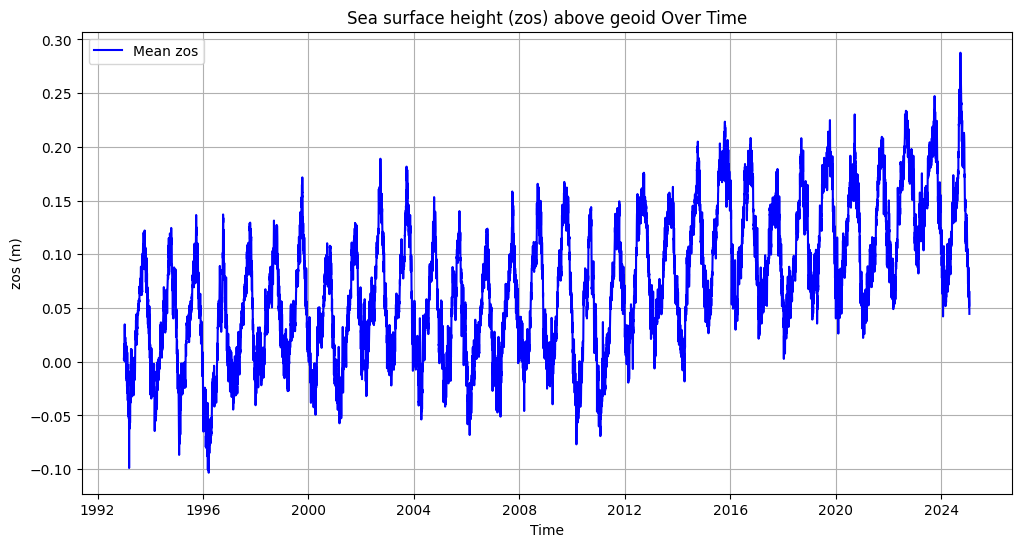

,time,zos
0,1993-01-01,0.002809
1,1993-01-02,0.001144
2,1993-01-03,0.016337
3,1993-01-04,0.005950
4,1993-01-05,0.015159
...,...,...
11711,2025-01-24,0.051383
11712,2025-01-25,0.053326
11713,2025-01-26,0.065663
11714,2025-01-27,0.045702


In [8]:
# Calculate the mean zos across latitude and longitude
mean_zos = ds.zos.mean(dim=('latitude', 'longitude'))

# Convert to a pandas DataFrame for more flexible plotting
mean_zos_df = mean_zos.to_dataframe().reset_index()

# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(mean_zos_df['time'], mean_zos_df['zos'], label='Mean zos', color='blue')
plt.title('Sea surface height (zos) above geoid Over Time')
plt.xlabel('Time')
plt.ylabel('zos (m)')
plt.legend()
plt.grid(True)
plt.savefig('figures/zos_mean.png')
plt.show()

display(mean_zos_df)

## 3. Detrending zos data

In [9]:
# # Extract data
# time = mean_zos_df['time'].values
# signal = mean_zos_df['zos'].values

# # Apply EMD
# emd = EMD()
# IMFs = emd(signal)

# # Plot the first four IMFs in separate subplots
# fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# for i in range(min(4, len(IMFs))):
#     axs[i].plot(time, IMFs[i], label=f'IMF {i + 1}')
#     axs[i].set_ylabel('zos (m)')
#     axs[i].legend(loc='upper right')
#     axs[i].grid(True)

# # Set common labels and title
# plt.suptitle('Intrinsic Mode Functions (IMFs) of zos', fontsize=16)
# axs[-1].set_xlabel('Time')

# plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust spacing to fit the title
# plt
# plt.show()


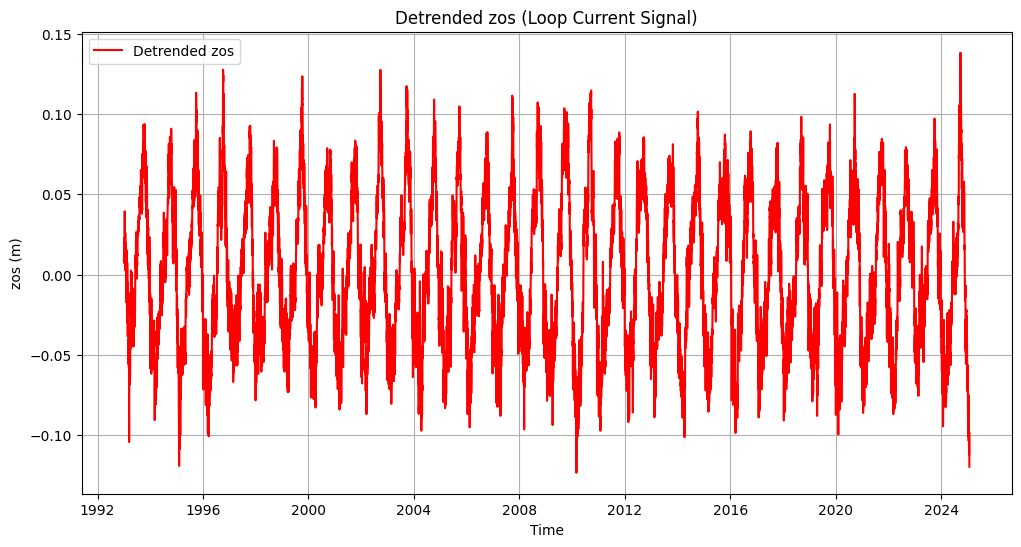

In [10]:
# Set 'time' column as index
mean_zos_df = mean_zos_df.set_index('time')

# Apply LOWESS to remove slow background trend
filtered = lowess(mean_zos_df['zos'], mean_zos_df.index, frac=0.05)

# Subtract trend
mean_zos_df['detrended_zos'] = mean_zos_df['zos'] - filtered[:, 1]

# Plot detrended data
plt.figure(figsize=(12, 6))
plt.plot(mean_zos_df.index, mean_zos_df['detrended_zos'], label='Detrended zos', color='red')
plt.title('Detrended zos (Loop Current Signal)')
plt.xlabel('Time')
plt.ylabel('zos (m)')
plt.legend()
plt.grid(True)

plt.savefig('figures/zos_mean_detrended.png')

plt.show()


In [11]:
# Ensure the output directory exists
output_dir = 'output'
os.makedirs(output_dir, exist_ok=True)

# Save only the 'time', 'zos', and 'detrended_zos' columns without the index
file_path = os.path.join(output_dir, 'zos_daily.csv')
mean_zos_df[[ 'zos', 'detrended_zos']].to_csv(file_path)

print(f"File saved to: {file_path}")
mean_zos_df

File saved to: output\zos_daily.csv


,zos,detrended_zos
time,,
1993-01-01,0.002809,0.009426
1993-01-02,0.001144,0.007580
1993-01-03,0.016337,0.022593
1993-01-04,0.005950,0.012026
1993-01-05,0.015159,0.021055
...,...,...
2025-01-24,0.051383,-0.112541
2025-01-25,0.053326,-0.110714
2025-01-26,0.065663,-0.098493
